# Clustering

#### In this assignment, you will implement a K-Means Clustering algorithm from scratch and compare the results to existing sklearn algorithm.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Question 1.1: Write a method that determine Labels from Points and ClusterCentroids, and return a list of a label for each point

In [2]:
def FindLabelOfClosest(Points, ClusterCentroids): # determine Labels from Points and ClusterCentroids
    NumberOfClusters, NumberOfDimensions = ClusterCentroids.shape # dimensions of the initial Centroids
    Distances = np.zeroes(NumberofClusters) # centroid distances
    NumberOfPoints, NumberOfDimensions = Points.shape
    Labels = np.zeroes(NumberOfPoints)
    for PointNumber in range(NumberOfPoints): # assign labels to all data points            
        for ClusterNumber in range(NumberOfClusters): # for each cluster
            # Get distances for each cluster
            Distances[ClusterNumber] = (np.linalg.norm(Points.iloc[PointNumber]-ClusterCentroids.iloc[ClusterNumber]))
        Labels[PointNumber] = np.argmin(Distances) #assign to closest cluster
    return Labels # return the a label for each point

#### Question 1.2: Write a method that determine centroid of Points with the same label

In [3]:
def CalculateClusterCentroid(Points, Labels): # determine centroid of Points with the same label
    ClusterLabels = np.unique(Labels) # names of labels
    NumberOfPoints, NumberOfDimensions = Points.shape
    ClusterCentroids = pd.DataFrame(0,index=np.arange(len(ClusterLabels)),columns=range(NumberOfDimensions))
    for ClusterNumber in ClusterLabels: # for each cluster
        # get mean for each label
        mean = Points[Labels==ClusterNumber].mean(axis=0)
        ClusterCentroids.loc[ClusterNumber, :] = mean
        print(ClusterCentroids[ClusterNumber])
    return ClusterCentroids # return the a label for each point

#### Question 1.3: Put it all together as such. K-means algorithm partitions the input data into K clusters by iterating between the following two steps:
- Compute the cluster center by computing the arithmetic mean of all the points belonging to the cluster.
- Assign each point to the closest cluster center.

In [4]:
def KMeans(Points, ClusterCentroidGuesses):
    #TODO
    ClusterCentroids = ClusterCentroidGuesses.copy()
    Labels_Previous = None
    # Get starting set of labels
    Labels = FindLabelOfClosest(Points, ClusterCentroids)
    while not np.array_equal(Labels, Labels_Previous):
        # Re-calculate cluster centers based on new set of labels
        ClusterCentroids = CalculateClusterCentroid(Points,Labels)
        Labels_Previous = Labels.copy() # Must make a deep copy
        # Determine new labels based on new cluster centers
        Labels = FindLabelOfClosest(Points,ClusterCentroids)
    return Labels, ClusterCentroids

In [5]:
StoreTxn = pd.read_csv("./Superstore Transaction data.csv")
StoreTxn['Order Date'] = pd.to_datetime(StoreTxn['Order Date'] )
StoreTxn.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
latest = StoreTxn["Order Date"].max()

#### Extract RFM features from the transaction data:
- Recency: when was the last purchase they made
- Frequency: how often do they make a purchase in the last month (or any given window you choose)
- Monetary: how much money did they spend in the last month

#### Question 2.1:
- Use groupby to summarize the quantity and dollar columns by user_id and date
- Name the aggregated data txn_agg
- Reset the index for txn_agg to the default and user_id and date to dataframe columns
- Confirm changes

In [7]:
txn_agg = StoreTxn.groupby(by=["Customer ID","Order Date"])[["Quantity","Sales"]].sum() #Summarize quantity and dollar by user_id - date.  
txn_agg.head(10)

Quantity     Sales
Customer ID Order Date                    
AA-10315    2014-03-31         4   726.548
            2014-09-15         5    29.500
            2015-10-04         2    26.960
            2016-03-03        14  4406.072
            2017-06-29         5   374.480
AA-10375    2014-04-21         5    16.520
            2014-10-24         3    34.272
            2015-02-03         5   178.370
            2015-05-08         2     5.248
            2015-11-13         6    84.960

#### Question 2.2: 
- Using the aggregated data, obtain recency, frequency and monetary features for both dollar and quantity. Use a 7-day moving window for frequency and monetary. Call your new features `last_visit_ndays` (recency) `quantity_roll_sum_7D` (frequency) and `dollar_roll_sum_7D` (monetary)

In [8]:
# Group the data by user_id and calculate lag as the differnce between the current and previous date (lag by one period)
last = StoreTxn.groupby(by=['Customer ID'], group_keys=True)['Order Date'].apply(lambda x: (x - x.shift(1)))
last = pd.DataFrame(last)
last.rename(columns = {'Order Date' : 'last_visit_ndays'}, inplace = True) # Name the lagged date values last_visit_ndays
print(last.head(10), end='\n\n')

# Group the data by user_id.  Apply a 7 day offset to implement a moving 7-day window totaling quantity and dollars sold within each time window. 
roll = StoreTxn.set_index('Order Date').groupby(by=['Customer ID'], group_keys=True).resample('7D')
# Name the resulting data values quantity_roll_sum_7D and dollar_roll_sum_7D
df = pd.DataFrame()
df["Quantity"] = roll["Quantity"].mean()
df["Sales"]    = roll["Sales"].mean()
roll = df
roll.rename(columns = {'Quantity' : 'Quantity_roll_sum_7D', 'Sales' : 'Sales_roll_sum_7D'}, inplace = True)
print(roll.head(10), end='\n\n')

                 last_visit_ndays
Customer ID                      
AA-10315    1159              NaT
            1160           0 days
            1299        -634 days
            2229        -552 days
            2230           0 days
            5198         703 days
            5199           0 days
            5200           0 days
            5201           0 days
            7468        -535 days

                        Quantity_roll_sum_7D  Sales_roll_sum_7D
Customer ID Order Date                                         
AA-10315    2014-03-31                   2.0            363.274
            2014-04-07                   NaN                NaN
            2014-04-14                   NaN                NaN
            2014-04-21                   NaN                NaN
            2014-04-28                   NaN                NaN
            2014-05-05                   NaN                NaN
            2014-05-12                   NaN                NaN
            201

Question 2.3: Combine all three features into a single DataFrame and call it txn_roll

In [9]:
StoreTxn["Quantity"],StoreTxn["Sales"],StoreTxn["Order Date"]

(0       2
 1       3
 2       2
 3       5
 4       2
        ..
 9989    3
 9990    2
 9991    2
 9992    4
 9993    2
 Name: Quantity, Length: 9994, dtype: int64,
 0       261.9600
 1       731.9400
 2        14.6200
 3       957.5775
 4        22.3680
           ...   
 9989     25.2480
 9990     91.9600
 9991    258.5760
 9992     29.6000
 9993    243.1600
 Name: Sales, Length: 9994, dtype: float64,
 0      2016-11-08
 1      2016-11-08
 2      2016-06-12
 3      2015-10-11
 4      2015-10-11
           ...    
 9989   2014-01-21
 9990   2017-02-26
 9991   2017-02-26
 9992   2017-02-26
 9993   2017-05-04
 Name: Order Date, Length: 9994, dtype: datetime64[ns])

In [10]:
customer_id = StoreTxn["Customer ID"].value_counts().index.tolist()

In [11]:
R,F,M,ids = [],[],[],[]
for _id in customer_id:
    t_first,t_last = StoreTxn[StoreTxn["Customer ID"] == _id]["Order Date"].min(),StoreTxn[StoreTxn["Customer ID"] == _id]["Order Date"].max()
    v_profit,n_quantity = StoreTxn[StoreTxn["Customer ID"] == _id]["Sales"].sum(),StoreTxn[StoreTxn["Customer ID"] == _id]["Quantity"].sum()
    frequency = n_quantity
    delta_t = (latest-t_first).days
    R.append(delta_t),F.append(frequency),M.append(v_profit),ids.append(_id)
RFM = pd.DataFrame(data={"Recency":R,"Frequency":F,"Monetary":M},index=ids)
RFM

,Recency,Frequency,Monetary
WB-21850,1152,146,6160.102
JL-15835,1352,143,9799.923
MA-17560,1240,117,4299.161
PP-18955,1222,138,7252.608
CK-12205,1390,122,3154.855
...,...,...,...
LD-16855,552,3,5.304
AO-10810,501,2,161.280
CJ-11875,365,5,16.520
RE-19405,1097,5,48.360


In [12]:
txn_roll = RFM
#Inner join between roll (frequency and monetary fields) and last (recency fields) to create churn_roll.
#Join based on index which works given that both dataframes are sorted by user_id and date.
print(txn_roll.dtypes, end='\n\n')
txn_roll.head(10)

Recency        int64
Frequency      int64
Monetary     float64
dtype: object



,Recency,Frequency,Monetary
WB-21850,1152,146,6160.1020
JL-15835,1352,143,9799.9230
MA-17560,1240,117,4299.1610
PP-18955,1222,138,7252.6080
CK-12205,1390,122,3154.8550
SV-20365,1449,109,11470.9500
JD-15895,1375,150,7610.8640
EH-13765,1358,120,10310.8800
ZC-21910,1174,105,8025.7070
EP-13915,1273,124,5478.0608


In [13]:
txn_roll["Recency"].value_counts()

1197    6
1209    6
1365    5
1370    5
1124    5
       ..
1231    1
881     1
736     1
1171    1
68      1
Name: Recency, Length: 446, dtype: int64

Question 2.4: Use fillna to replace missing values for recency with a large value like 100 days (whatever makes business sense). HINT: You can use pd.Timedelta('100 days') to set the value.

Question 2.5: Merge the aggregated data churn_agg with the RFM features in churn_roll. You can use the merge method to do this with the right keys specified.

Question 3.1: Train the k-means algorithm you developed earlier on the RFM features using  𝑘=4 . What are the cluster centroids? The cluster centroids should be reported in the original scale, not the standardized scale.

In [14]:
from sklearn.cluster import KMeans

X = RFM.values
model = KMeans(n_clusters=4, n_init="auto").fit(X)
ClusterCentroidGuesses = model.fit_predict(X)

#Labels, ClusterCentroids = KMeans(txn_rfm, ClusterCentroidGuesses)

Question 3.2: Pick few pairs and plot scatter plots along with cluster centroids.

In [15]:
RFM["Cluster"] = ClusterCentroidGuesses
RFM

,Recency,Frequency,Monetary,Cluster
WB-21850,1152,146,6160.102,1
JL-15835,1352,143,9799.923,1
MA-17560,1240,117,4299.161,2
PP-18955,1222,138,7252.608,1
CK-12205,1390,122,3154.855,2
...,...,...,...,...
LD-16855,552,3,5.304,0
AO-10810,501,2,161.280,0
CJ-11875,365,5,16.520,0
RE-19405,1097,5,48.360,0


In [16]:
test_points = RFM.iloc[[9,25,36,49,64,81]]
test_points

,Recency,Frequency,Monetary,Cluster
EP-13915,1273,124,5478.0608,1
CB-12025,1380,122,6076.1390,1
BH-11710,1300,97,6255.3510,1
AH-10690,1368,102,7888.2940,1
AM-10705,1156,81,5664.0220,1
RD-19900,1365,85,3133.9240,2


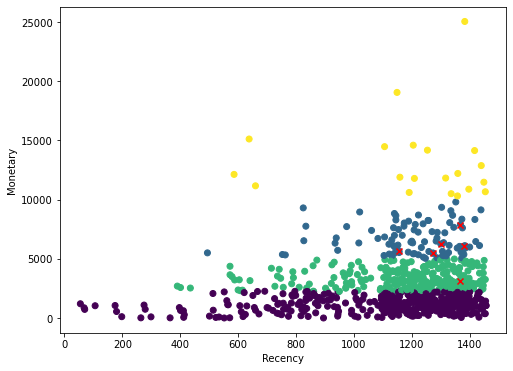

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(RFM["Recency"], RFM["Monetary"], marker="o", c=RFM["Cluster"])
plt.scatter(test_points["Recency"],test_points["Monetary"],marker="x",c="red")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

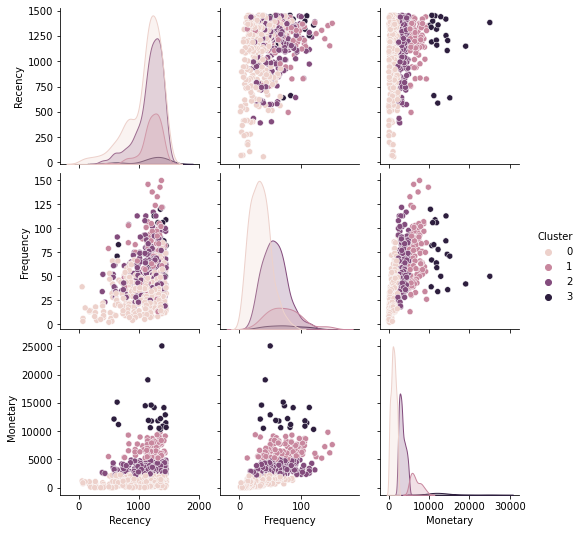

In [18]:
import seaborn as sns

sns.pairplot(RFM, hue="Cluster")

plt.show()

Question 5: Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include: What was your incoming experience with this model, if any? what steps you took, what obstacles you encountered. how you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.